# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and robust machine learning.
The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

In [ ]:
import os
if not os.path.exists('zh03-causal-discovery-robust-predictions'):
    !git clone https://github.com/WinterSchool2026/zh03-causal-discovery-robust-predictions.git
import sys
sys.path.insert(0, 'zh03-causal-discovery-robust-predictions')

In [1]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Custom modules / Causal discovery
from src.causal_feature_selection import (
    hiton_mb, iamb, mmpc, mb_ges, resit_mb, hiton_pc
)

# Data generation
from src.generate_scm import *

np.random.seed(2)

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


---
## Section 4 — CFS for Robust Prediction

### 4.1 The distribution shift problem

Standard machine learning optimizes for expected loss on training data. In deployment, the distribution may shift. We focus here on **intervention shifts**: an external agent forces a variable to a particular value, breaking its natural causal mechanism.

Formally, an intervention do(X_i = v) replaces the structural equation for X_i, which propagates to all downstream variables. The key question: which predictors of Y remain reliable after such interventions?

### 4.2 Why standard predictors degrade

Consider a graph where A → Y ← B → C. Under the training distribution, C correlates with Y via B, and a full regression on {A, B, C} will assign weight to C. But if we intervene on B — say in a new hospital where B is controlled — the B → C edge is severed. C no longer tracks Y the way it did in training. The predictor breaks.

The structural equation for Y is:

$$Y = f(\text{PA}(Y)) + \varepsilon_Y$$

This equation is **invariant** to interventions on any variable other than Y itself. Parents of Y are therefore the most robust feature set.

### 4.3 Setup: SCM with `generate_dag`

We use `generate_dag` and `fit_from_adjacency` to build a controlled SCM, then track which nodes are parents, children, spouses, and unrelated ("others") with respect to Y.


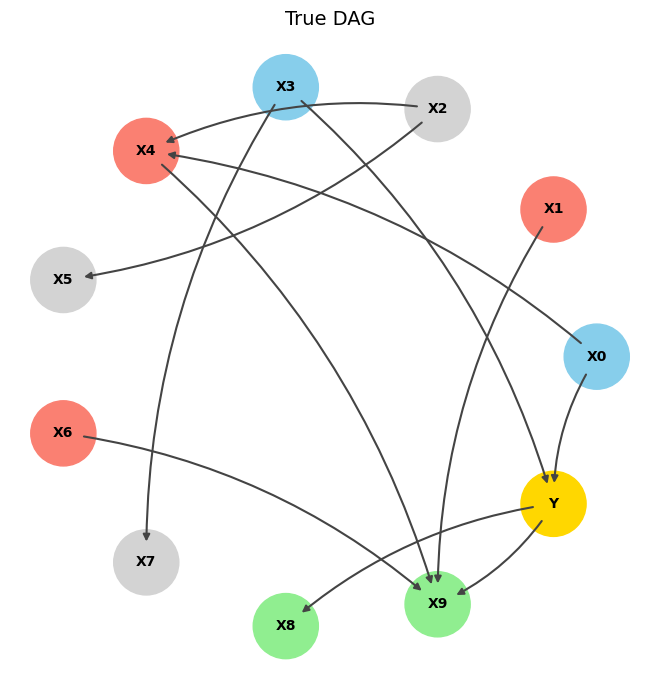

Parents of Y:  [np.int64(0), np.int64(3)]
Children of Y: [np.int64(8), np.int64(9)]
Spouses of Y:  [np.int64(1), np.int64(4), np.int64(6)]
Others:        [np.int64(2), np.int64(5), np.int64(7)]


In [2]:
# Build SCM from an explicit random DAG
d = 10
scm = SCMGenerator(d=d)
A = generate_dag(num_vars=d+1, n_parents=2, n_children=2, n_spouses=1, sparsity=0.15)
scm.fit_from_adjacency(A, Y_idx=d, noise_type='uniform', is_linear=True)

col_names = np.hstack((np.array([f'X{i}' for i in range(scm.n_nodes-1)]), np.array(['Y'])))
plot_graphs_from_adj([scm.A], [d], [col_names], ['True DAG'])

print("Parents of Y: ", sorted(scm.parents_idx))
print("Children of Y:", sorted(scm.children_idx))
print("Spouses of Y: ", sorted(scm.spouses_idx))
print("Others:       ", sorted(scm.others_idx))


In [3]:
# Sample observational data and run CFS algorithms
data = scm.sample(n_samples=10000)
data.head()


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
0,0.354279,-0.740157,0.186835,0.176096,-0.452674,0.248889,0.798381,-0.223523,-0.289031,-2.510705,-0.358854
1,0.771655,-0.653054,0.298281,0.193829,-0.406084,-0.095922,-0.656386,-0.013901,0.073371,-1.031143,-0.277159
2,-0.692869,0.339463,-0.291369,-0.567684,0.580701,-0.174434,-0.868307,0.480409,0.010348,2.163831,-0.130672
3,0.893388,-0.301502,-0.109091,0.722457,-1.175593,-0.427206,-0.256731,-0.829155,-0.119557,-1.600267,-0.011260
4,-0.412513,-0.888684,0.408724,-0.682047,1.031774,0.479356,-0.950977,0.866265,-0.707588,0.620497,-0.340668


In [4]:
# Run several MB/CFS algorithms on the observational data
# ------------------------------------------------------------

# HITON-MB
start = time.time()
mb_hiton = hiton_mb(data, 'Y', alpha=0.05, ci_method='partial')
print(f"HITON-MB  : {time.time()-start:.2f}s  ->  {sorted(mb_hiton)}")

# HITON-PC  (parents + children only, no spouses)
start = time.time()
mb_hiton_pc = hiton_pc(data, 'Y', alpha=0.05, ci_method='partial')
print(f"HITON-PC  : {time.time()-start:.2f}s  ->  {sorted(mb_hiton_pc)}")

# IAMB
start = time.time()
mb_iamb = iamb(data, 'Y', alpha=0.05, ci_method='partial')
print(f"IAMB      : {time.time()-start:.2f}s  ->  {sorted(mb_iamb)}")

# MB-GES
start = time.time()
mb_ges_result = mb_ges(data, 'Y')
print(f"MB-GES    : {time.time()-start:.2f}s  ->  {sorted(mb_ges_result)}")

# RESIT-MB (also returns estimated parents)
start = time.time()
mb_resit, parents_resit = resit_mb(data, 'Y', alpha=0.05, return_parents=True)
print(f"RESIT-MB  : {time.time()-start:.2f}s  ->  {sorted(mb_resit)}")
print(f"  RESIT parents: {sorted(parents_resit)}")

true_mb = set(scm.parents_idx) | set(scm.children_idx) | set(scm.spouses_idx)
print(f"\nTrue MB:    {sorted(true_mb)}")
print(f"True parents: {sorted(scm.parents_idx)}")


HITON-MB  : 1.66s  ->  ['X0', 'X1', 'X3', 'X4', 'X6', 'X8', 'X9']
HITON-PC  : 0.47s  ->  ['X0', 'X3', 'X8', 'X9']
IAMB      : 0.49s  ->  ['X0', 'X1', 'X3', 'X4', 'X6', 'X8', 'X9']
MB-GES    : 0.34s  ->  ['X0', 'X1', 'X3', 'X4', 'X6', 'X8', 'X9']
RESIT-MB  : 0.80s  ->  ['X5']
  RESIT parents: []

True MB:    [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(8), np.int64(9)]
True parents: [np.int64(0), np.int64(3)]


### 4.4 Robustness under intervention: MB vs full predictor

We now compare two predictors:
- **Full predictor**: trained on all features
- **MB predictor**: trained on the MB-GES estimated feature set

We evaluate both as we sweep the intervention value on each group of nodes (parents, children, spouses, others). This produces R² curves as a function of intervention strength.

The design reveals something important: different groups of nodes have different effects on the predictor when intervened on.


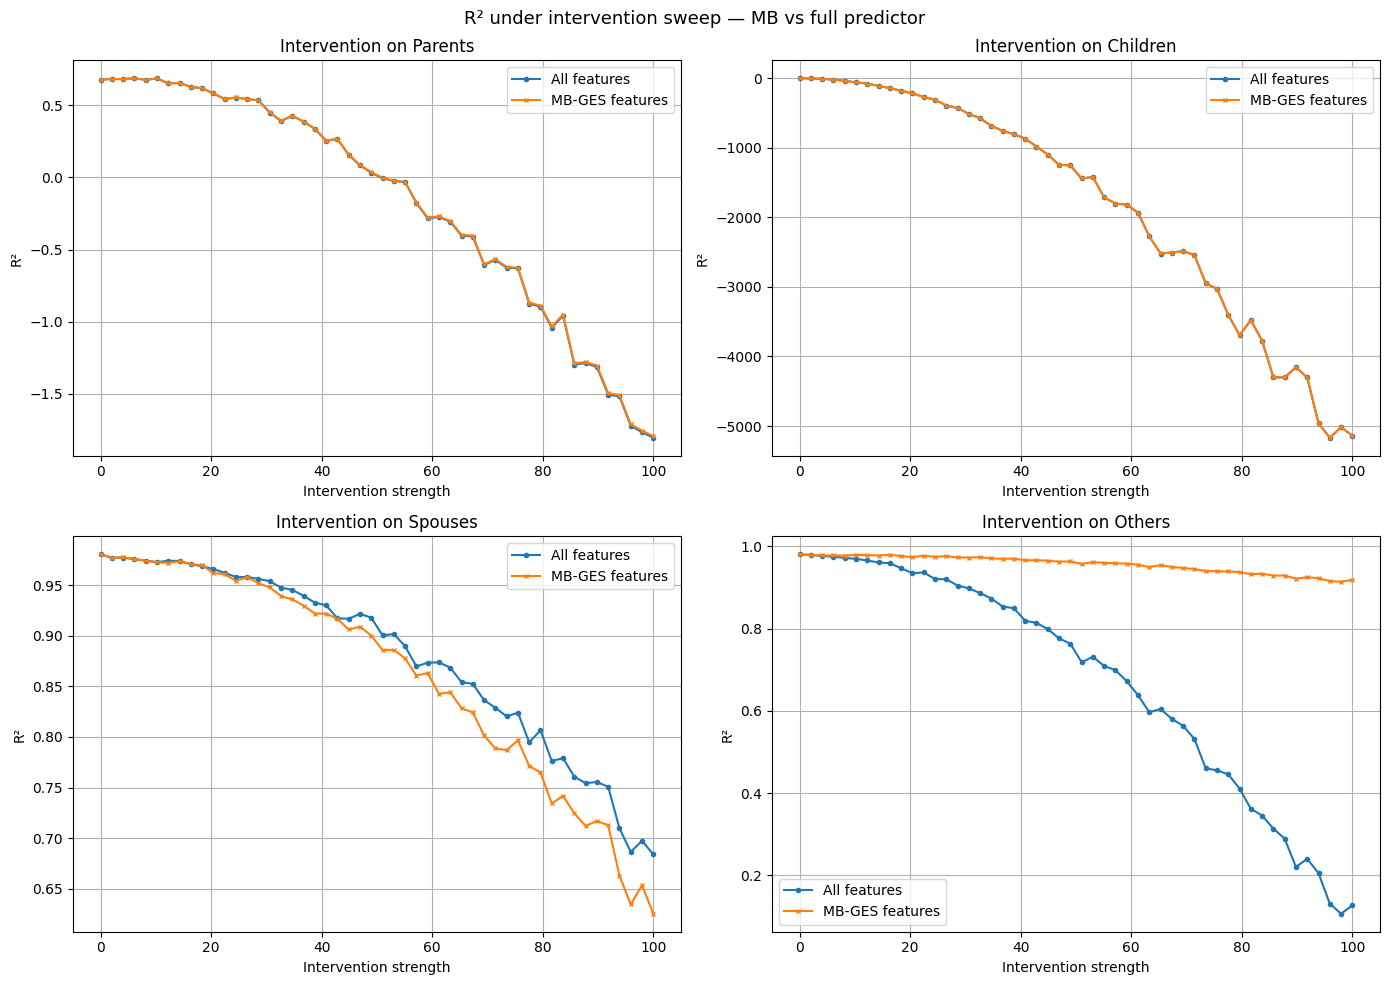

In [5]:
# Fit predictors on observational data
lr_full = LinearRegression().fit(data.drop(columns='Y').values, data['Y'].values)
lr_ges  = LinearRegression().fit(data[mb_ges_result].values, data['Y'].values)

# Sweep intervention values across node groups
intervention_values = np.linspace(0, 100, 50)

intervention_groups = {
    'Parents':  scm.parents_idx,
    'Children': scm.children_idx,
    'Spouses':  scm.spouses_idx,
    'Others':   scm.others_idx
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (group_name, indices) in enumerate(intervention_groups.items()):
    r2_full, r2_ges = [], []
    indices_list = list(indices)

    for val in intervention_values:
        scm_int = scm.intervention(indices=indices_list, values=[val]*len(indices_list))
        data_int = scm_int.sample(n_samples=1000)

        r2_full.append(lr_full.score(data_int.drop(columns='Y').values, data_int['Y'].values))
        r2_ges.append(lr_ges.score(data_int[mb_ges_result].values, data_int['Y'].values))

    axes[i].plot(intervention_values, r2_full, label='All features', marker='o', markersize=3)
    axes[i].plot(intervention_values, r2_ges,  label='MB-GES features', marker='x', markersize=3)
    axes[i].set_title(f'Intervention on {group_name}')
    axes[i].set_xlabel('Intervention strength')
    axes[i].set_ylabel('R²')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle('R² under intervention sweep — MB vs full predictor', fontsize=13)
plt.tight_layout()
plt.show()


### 4.5 Using HITON-PC: closer to parent set

HITON-PC returns only the parents and children of Y (the PC set), not spouses. Since spouses are not parents of Y, they don't appear in Y's structural equation. The HITON-PC set is a subset of the MB that sits closer to the true causal mechanism.

Let's repeat the experiment with HITON-PC features.


HITON-PC features: ['X0', 'X3', 'X8', 'X9']
True parents:      [np.int64(0), np.int64(3)]
True PC set:       [np.int64(0), np.int64(3), np.int64(8), np.int64(9)]


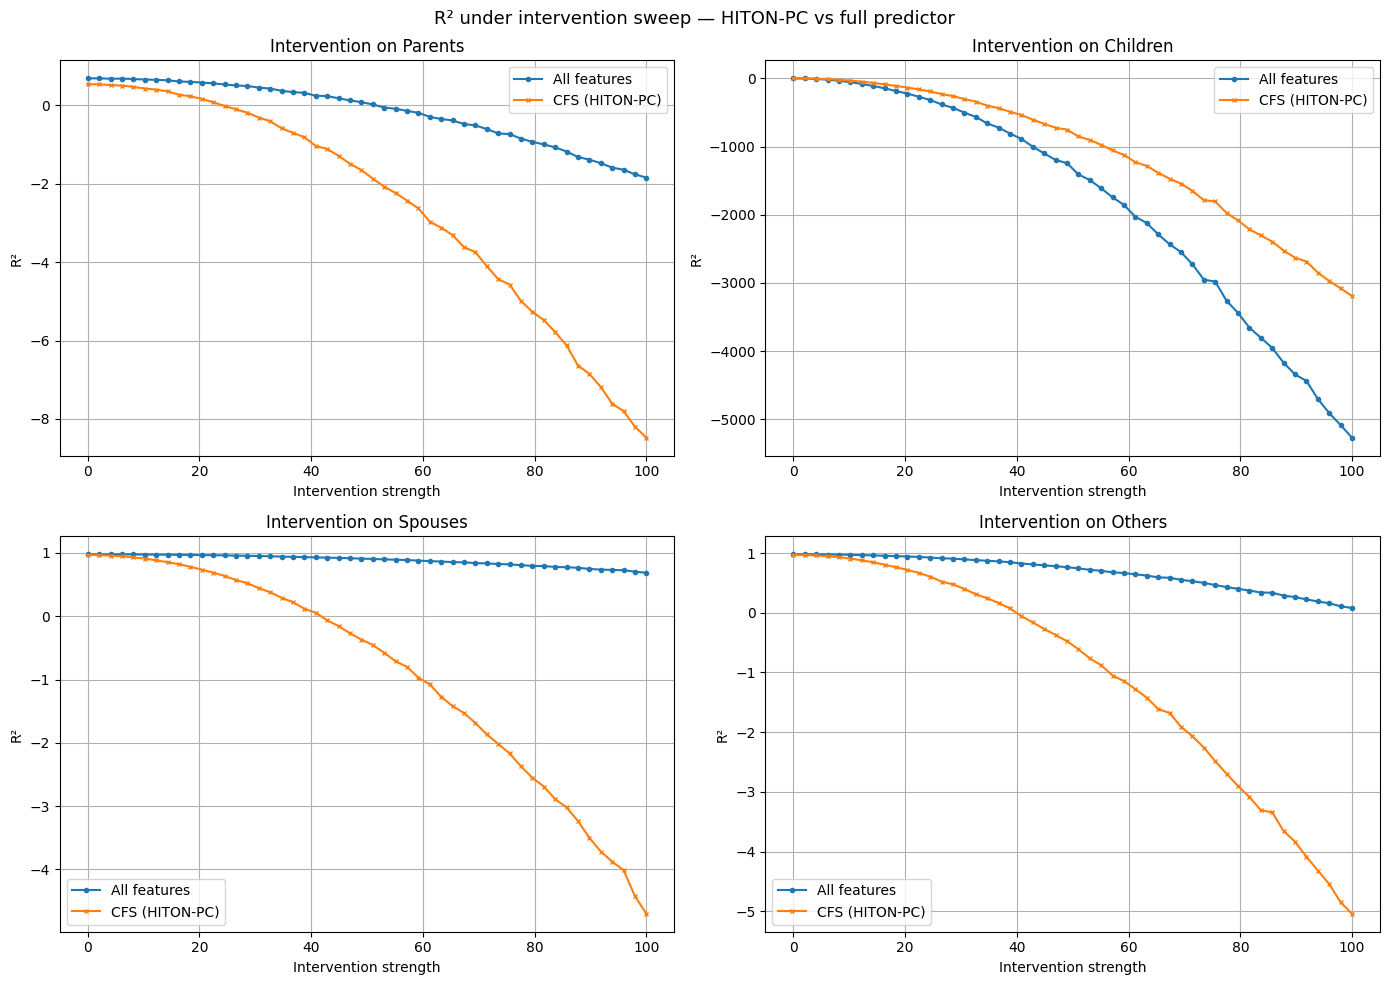

In [6]:
# Fit a predictor on HITON-PC features
lr_pc = LinearRegression().fit(data[mb_hiton_pc].values, data['Y'].values)

print(f"HITON-PC features: {sorted(mb_hiton_pc)}")
print(f"True parents:      {sorted(scm.parents_idx)}")
print(f"True PC set:       {sorted(set(scm.parents_idx) | set(scm.children_idx))}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (group_name, indices) in enumerate(intervention_groups.items()):
    r2_full, r2_pc = [], []
    indices_list = list(indices)

    for val in intervention_values:
        scm_int = scm.intervention(indices=indices_list, values=[val]*len(indices_list))
        data_int = scm_int.sample(n_samples=10000)

        r2_full.append(lr_full.score(data_int.drop(columns='Y').values, data_int['Y'].values))
        r2_pc.append(lr_pc.score(data_int[mb_hiton_pc].values, data_int['Y'].values))

    axes[i].plot(intervention_values, r2_full, label='All features', marker='o', markersize=3)
    axes[i].plot(intervention_values, r2_pc,   label='CFS (HITON-PC)', marker='x', markersize=3)
    axes[i].set_title(f'Intervention on {group_name}')
    axes[i].set_xlabel('Intervention strength')
    axes[i].set_ylabel('R²')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle('R² under intervention sweep — HITON-PC vs full predictor', fontsize=13)
plt.tight_layout()
plt.show()


# ADDING A PART ON EDGE ORIENTATION USING ANMs

### Questions — CFS for Robust Prediction

**Q15.** Look at the "Intervention on Children" plot. Explain why the MB-based predictor degrades here but the parent-based predictor would not. What is it about children in the structural equations that makes them unreliable features under intervention?

**Q16.** In the "Intervention on Others" panel, both predictors should be similarly stable. Why? Under what conditions could intervening on an "other" variable still harm the full predictor?

**Q17.** The R² of the full predictor in the "Intervention on Parents" panel typically drops as the intervention strength grows. Does this mean the parent-based predictor also fails? Think carefully about what R² measures when the marginal distribution of X changes.

**Q18.** HITON-PC returns parents and children, but not spouses. In which intervention scenario would you expect HITON-PC to be *more robust* than MB-GES, and why?


**Answers:**

**A15.** Children of Y appear in Y's structural equation only as *effects*, not causes. Their correlation with Y in the training data is indirect: child C is correlated with Y because Y causes C. When we intervene on C (do(C=v)), we break the C's mechanism but Y's equation is unchanged — Y still takes the same value it would have without the intervention on C. However, a predictor that *uses* C as a feature expects to see the natural C↔Y correlation. Under the intervention, C is set to a constant regardless of Y, so the feature is now uninformative. The predictor fails. Parents don't have this problem: Y's equation reads Y = f(parents) + ε, and this identity holds regardless of what happens to downstream nodes.

**A16.** "Others" are nodes with no direct path to or from Y in the local neighborhood. An intervention on an "other" node changes its value and possibly the values of its descendants — but if none of those descendants appear as features in the predictor, no feature shifts. The full predictor can still degrade if one of the "others" is an ancestor of a feature used in the model (the feature's distribution shifts, and the model extrapolates). This is precisely why conditioning on more features is not always better: each additional feature is a new potential point of failure.

**A17.** The R² drop when intervening on parents does not mean the parent-based predictor fails. What is happening is that the marginal distribution of the parent has changed (its variance has collapsed to zero since it's set to a constant). The explained variance ratio (R²) is a normalized metric; when all units have the same parent value, variance in Y is purely from noise, and R² ≈ 0 by definition — even a perfect predictor would score 0. MSE (or absolute error) is a better robustness metric when the intervention collapses variance in the input. The structural relationship Y = f(parents) + ε is still intact; R² just becomes a misleading metric here.

**A18.** HITON-PC would be more robust than MB-GES specifically when we intervene on a *spouse* of Y. Spouses are the other parents of Y's children. MB-GES includes them as features (they are in the MB), and their distribution changes under the intervention. HITON-PC does not include spouses, so that feature is absent and cannot corrupt the prediction. The tradeoff is that HITON-PC loses some predictive power in the observational regime (spouses carry signal about Y through their shared children), but gains robustness to spouse interventions.


### Exercise 4 — Head-to-head comparison of all selectors

Train four predictors — all features, MB-GES, HITON-PC, and true parents — and plot all four R² curves on the same axes for each intervention group. Which selector strikes the best balance between observational accuracy and robustness?


In [7]:
# Your code here
# Hint: fit LinearRegression on:
#   1) data.drop(columns='Y').values
#   2) data[mb_ges_result].values
#   3) data[mb_hiton_pc].values
#   4) data[[f'X{i}' for i in scm.parents_idx]].values
# Then produce 4-panel plot as above with all four curves per panel.
